In [2]:
import rqdatac as rq
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import RFECV
from sklearn.metrics import r2_score, mean_absolute_error

# Log in to rqdatac
rq.init()


# Industry code/name depends on classification system
# industry_name = "电子" # 电子 code 60
industry_name = "半导体" # 非银行金融 code 41

# Get all A-shares
stocks = rq.all_instruments(type='CS')

# Get industry mapping
# industry_info = rq.get_instrument_industry(stocks.order_book_id.tolist())

# Filter
# finance_stocks = industry_info[
#     industry_info['first_industry_name'] == industry_name
# ]
finance_stocks = stocks

print(finance_stocks.head())

print(f"number of stocks: {len(finance_stocks)}")

/Users/tylerpruitt/Desktop/量化投资交易/Quant Trading Desk/.venv/lib/python3.8/site-packages/rqdatac/client.py:224: UserWarning: rqdatac is already inited. Settings will be changed.
  warnings.warn("rqdatac is already inited. Settings will be changed.", stacklevel=0)


  order_book_id industry_code  market_tplus symbol special_type exchange  \
0   000001.XSHE           J66             1   平安银行       Normal     XSHE   
1   000002.XSHE           K70             1    万科A       Normal     XSHE   
2   000003.XSHE       Unknown             1  PT金田A           PT     XSHE   
3   000004.XSHE           I65             1  *ST国华       StarST     XSHE   
4   000005.XSHE       Unknown             1   ST星源        Other     XSHE   

     status type de_listed_date listed_date  ...            sector_code  \
0    Active   CS     0000-00-00  1991-04-03  ...             Financials   
1    Active   CS     0000-00-00  1991-01-29  ...             RealEstate   
2  Delisted   CS     2002-06-14  1991-07-03  ...                Unknown   
3    Active   CS     0000-00-00  1990-12-01  ...  InformationTechnology   
4  Delisted   CS     2024-04-26  1990-12-10  ...                Unknown   

  round_lot            trading_hours  board_type industry_name issue_price  \
0     100.0  0

In [4]:
start_date = '2010-01-01'
end_date = '2025-12-31'

factors = [
    # valuation
    'pe_ratio',
    'pb_ratio',
    'ps_ratio',
    'pcf_ratio',

    # profitability
    'return_on_equity',
    'return_on_asset',

    # leverage/liquidity
    'debt_to_equity',
    'current_ratio',
    
    # growth
    'revenue_growth_rate',
    'net_profit_growth_rate',
    'peg_ratio_ttm',

    # profit margin
    'gross_profit_margin',

    # accounting
    'account_receivable_turnover_rate',
    'net_operate_cash_flow_growth_ratio_ttm',
]

# # Fetch financial statement ratio information
# finance_stock_codes = finance_stocks.index.tolist()
financial_data = rq.get_factor(finance_stocks['order_book_id'], factors, start_date=start_date, end_date=end_date)
print("financial data:")
print(financial_data.head(5))

financial_data = financial_data.fillna(0, inplace=False)
print('financial_data:')
print(financial_data.head(5))

financial data:
                          pe_ratio  pb_ratio  ps_ratio  pcf_ratio  \
order_book_id date                                                  
002536.XSHE   2011-01-11   39.3715   12.8027    3.9063    84.3654   
              2011-01-12   37.8611   12.3116    3.7564    81.1290   
              2011-01-13   38.8510   12.6334    3.8546    83.2501   
              2011-01-14   36.1263   11.7474    3.5843    77.4115   
              2011-01-17   33.4933   10.8912    3.3230    71.7696   

                          return_on_equity  return_on_asset  debt_to_equity  \
order_book_id date                                                            
002536.XSHE   2011-01-11           26.8823           9.8108             NaN   
              2011-01-12           26.8823           9.8108             NaN   
              2011-01-13           26.8823           9.8108             NaN   
              2011-01-14           26.8823           9.8108             NaN   
              2011-01-17  

In [6]:
financial_data_reset = financial_data.reset_index()

financial_data_reset['date'] = pd.to_datetime(
    financial_data_reset['date']
)

financial_data_monthly = (
    financial_data_reset
    .groupby([
        'order_book_id',
        pd.Grouper(key='date', freq='M')
    ])
    .last()
    .reset_index()
)

financial_data = financial_data_monthly

print(financial_data.head())

  order_book_id       date  pe_ratio  pb_ratio  ps_ratio  pcf_ratio  \
0   000001.XSHE 2010-01-31   72.1143    3.5303    4.5270     2.7683   
1   000001.XSHE 2010-02-28   74.6067    3.6523    4.6835     2.8640   
2   000001.XSHE 2010-03-31   14.3212    3.5197    4.7667     2.2379   
3   000001.XSHE 2010-04-30   11.6367    2.8878    4.1357     1.9832   
4   000001.XSHE 2010-05-31    9.9104    2.4594    3.5222     1.6890   

   return_on_equity  return_on_asset  debt_to_equity  current_ratio  \
0           20.4987              0.0             0.0            0.0   
1           20.4987              0.0             0.0            0.0   
2           27.2887              0.0             0.0            0.0   
3            7.4126              0.0             0.0            0.0   
4            7.4126              0.0             0.0            0.0   

   revenue_growth_rate  net_profit_growth_rate  peg_ratio_ttm  \
0                  0.0                     0.0      -0.934475   
1               

In [ ]:
# 数据预处理与标准化
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 本实验采用均值填充法处理缺失值，避免因财务指标缺失导致模型无法训练。
X = financial_data[factors]

imputer = SimpleImputer(strategy='mean')

X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=factors,
    index=financial_data.index
)

X_scaled.head()

ValueError: Input X contains infinity or a value too large for dtype('float64').

## 模型A：孤立森林

In [58]:
# 模型A：（孤立森林 Isolation Forest）：基于树结构的随机划分，擅长在高维空间中快速识别全局离群点；

from sklearn.ensemble import IsolationForest

# 构建模型
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

# 训练模型
iso_forest.fit(X_scaled)

# 异常预测
# 正常点：1
# 异常点：-1
iso_labels = iso_forest.predict(X_scaled)

# 异常得分
iso_scores = iso_forest.decision_function(X_scaled)

# 添加结果
financial_data['iso_label'] = iso_labels
financial_data['iso_score'] = iso_scores

financial_data[['iso_label', 'iso_score']].head()

,iso_label,iso_score
0,1,0.085149
1,1,0.088317
2,1,0.085149
3,1,0.129318
4,1,0.129318


### 异常结果分析

其中：

- `iso_label = -1`
表示模型判定为异常公司；

- `iso_score`
表示异常程度：
分数越低 → 越异常；
分数越高 → 越正常。

In [59]:
# 提取异常样本
iso_anomalies = financial_data[financial_data['iso_label'] == -1]

print("异常样本数量：", len(iso_anomalies))

iso_anomalies.head()

异常样本数量： 493


,order_book_id,date,pe_ratio,pb_ratio,ps_ratio,pcf_ratio,return_on_equity,return_on_asset,debt_to_equity,current_ratio,revenue_growth_rate,net_profit_growth_rate,peg_ratio_ttm,gross_profit_margin,account_receivable_turnover_rate,net_operate_cash_flow_growth_ratio_ttm,iso_label,iso_score
134,000415.XSHE,2010-03-31,-31.8463,10.7759,10.7420,12.5079,-29.0337,-5.9712,0.0,0.898263,0.0,0.0,38.762496,11.246274,2.1401,0.000000,-1,-0.005539
147,000415.XSHE,2011-04-30,2190.6959,15.9514,12.3136,109.8298,-0.2317,-0.0764,0.0,0.905943,0.0,0.0,-21.438026,11.242849,0.1892,-0.903125,-1,-0.000421
149,000415.XSHE,2011-06-30,2212.1249,16.1074,12.4341,110.9041,-0.2317,-0.0764,0.0,0.905943,0.0,0.0,-21.647728,11.242849,0.1892,-0.903125,-1,-0.003194
150,000415.XSHE,2011-07-31,7255.6023,52.8311,40.7828,363.7571,-0.2317,-0.0764,0.0,0.905943,0.0,0.0,-71.002912,11.242849,0.1892,-0.903125,-1,-0.100930
600,000617.XSHE,2017-01-31,-653.5263,527.2743,308.8580,-6759.6528,-0.7406,-0.0421,0.0,0.853049,0.0,0.0,-3.502579,-3.651500,0.4945,-1.481248,-1,-0.117079


### 可视化异常检测结果

这里使用二维特征进行可视化：

- 横轴：市盈率（PE）
- 纵轴：市净率（PB）

红色点表示孤立森林识别出的异常公司。

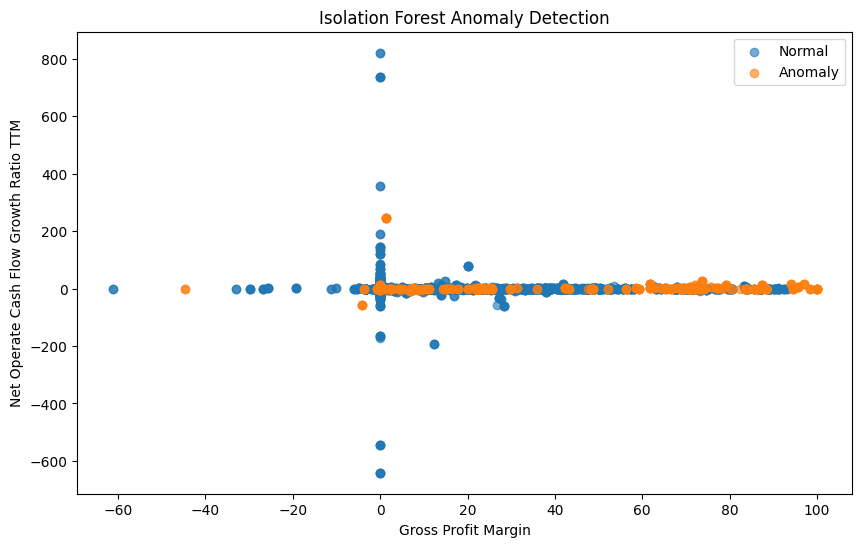

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

normal_points = financial_data[financial_data['iso_label'] == 1]
anomaly_points = financial_data[financial_data['iso_label'] == -1]

# 正常点
plt.scatter(
    normal_points['gross_profit_margin'],
    normal_points['net_operate_cash_flow_growth_ratio_ttm'],
    label='Normal',
    alpha=0.6
)

# 异常点
plt.scatter(
    anomaly_points['gross_profit_margin'],
    anomaly_points['net_operate_cash_flow_growth_ratio_ttm'],
    label='Anomaly',
    alpha=0.6
)

plt.xlabel('Gross Profit Margin')
plt.ylabel('Net Operate Cash Flow Growth Ratio TTM')
plt.title('Isolation Forest Anomaly Detection')
plt.legend()

plt.show()

## 模型B：DBSCAN 密度聚类

In [61]:
# 模型B: DBSCAN

from sklearn.cluster import DBSCAN

# 构建 DBSCAN 模型
dbscan = DBSCAN(
    eps=0.5,
    min_samples=15,
    algorithm='ball_tree',
)

# 模型训练
dbscan.fit(X_scaled)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.5
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",15
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'ball_tree'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [62]:
# 获取聚类结果
dbscan_labels = dbscan.labels_

# 保存结果
financial_data['dbscan_label'] = dbscan_labels

financial_data[['dbscan_label']].head()

# DBSCAN异常点
dbscan_anomalies = financial_data[
    financial_data['dbscan_label'] == -1
]

print("DBSCAN识别出的异常样本数量:", len(dbscan_anomalies))

dbscan_anomalies.head()

# 查看各类别数量
financial_data['dbscan_label'].value_counts()

DBSCAN识别出的异常样本数量: 1000


dbscan_label
 0    8840
-1    1000
 1      17
Name: count, dtype: int64

### 可视化 DBSCAN 异常检测结果

这里使用：

- 横轴：PE Ratio
- 纵轴：PB Ratio

进行二维可视化。

红色点表示DBSCAN识别出的异常公司。

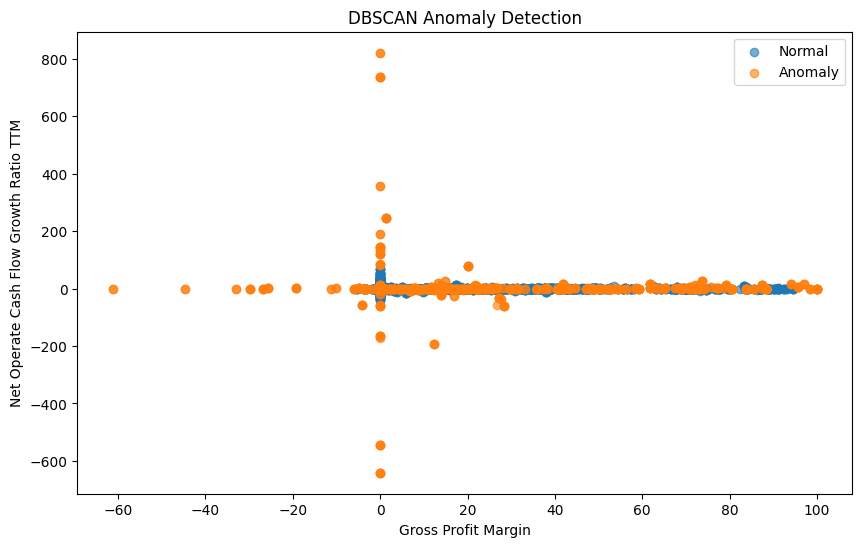

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 正常点
normal_points = financial_data[
    financial_data['dbscan_label'] != -1
]

# 异常点
anomaly_points = financial_data[
    financial_data['dbscan_label'] == -1
]

# 绘制正常点
plt.scatter(
    normal_points['gross_profit_margin'],
    normal_points['net_operate_cash_flow_growth_ratio_ttm'],
    alpha=0.6,
    label='Normal'
)

# 绘制异常点
plt.scatter(
    anomaly_points['gross_profit_margin'],
    anomaly_points['net_operate_cash_flow_growth_ratio_ttm'],
    alpha=0.6,
    label='Anomaly'
)

plt.xlabel('Gross Profit Margin')
plt.ylabel('Net Operate Cash Flow Growth Ratio TTM')

plt.title('DBSCAN Anomaly Detection')

plt.legend()

plt.show()

### 可选优化

In [64]:
# 统计异常比例
anomaly_ratio = (
    financial_data['dbscan_label'] == -1
).mean()

print("异常比例：", anomaly_ratio)

异常比例： 0.10145074566298062


## 模型C：3σ法则 / Z-score

In [65]:
from scipy import stats
import numpy as np

# 计算 Z-score
z_scores = np.abs(stats.zscore(X_scaled))

# 查看结果形状
print(z_scores.shape)

threshold = 3

# 任意特征超过阈值则视为异常
zscore_labels = (z_scores > threshold).any(axis=1)

# 转换为整数标签
# 正常：0
# 异常：1
zscore_labels = zscore_labels.astype(int)

# 保存结果
financial_data['zscore_label'] = zscore_labels

financial_data[['zscore_label']].head()

# 提取异常公司
zscore_anomalies = financial_data[
    financial_data['zscore_label'] == 1
]

print("Z-score识别出的异常样本数量:", len(zscore_anomalies))

zscore_anomalies.head()

anomaly_ratio = financial_data['zscore_label'].mean()

print("异常比例:", anomaly_ratio)

(9857, 14)
Z-score识别出的异常样本数量: 856
异常比例: 0.08684183828751141


### 可视化异常检测结果

这里使用：

- 横轴：PE Ratio
- 纵轴：PB Ratio

展示异常分布情况。

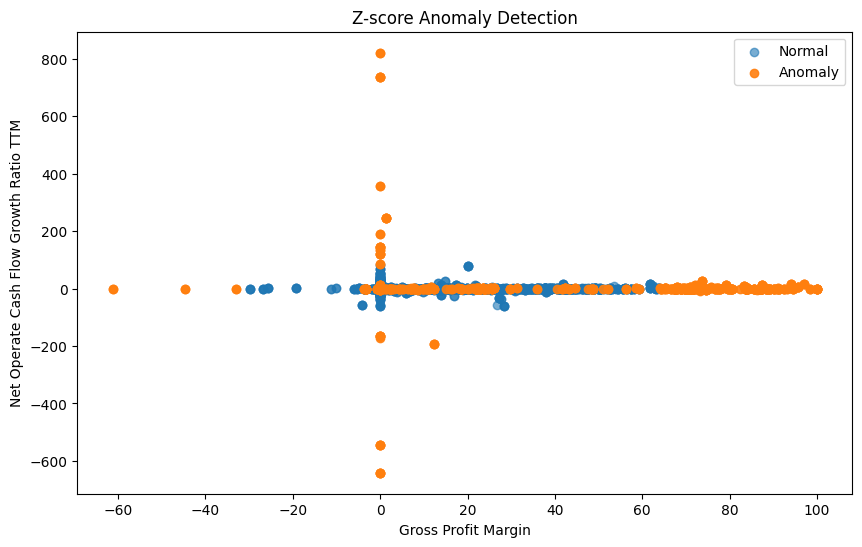

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 正常样本
normal_points = financial_data[
    financial_data['zscore_label'] == 0
]

# 异常样本
anomaly_points = financial_data[
    financial_data['zscore_label'] == 1
]

# 绘制正常点
plt.scatter(
    normal_points['gross_profit_margin'],
    normal_points['net_operate_cash_flow_growth_ratio_ttm'],
    alpha=0.6,
    label='Normal'
)

# 绘制异常点
plt.scatter(
    anomaly_points['gross_profit_margin'],
    anomaly_points['net_operate_cash_flow_growth_ratio_ttm'],
    alpha=0.9,
    label='Anomaly'
)

plt.xlabel('Gross Profit Margin')
plt.ylabel('Net Operate Cash Flow Growth Ratio TTM')

plt.title('Z-score Anomaly Detection')

plt.legend()

plt.show()

## 综合三个模型的输出，生成多视角的异常检测评估体系

注意：
- normal = 0
- anomaly = 1

In [67]:
financial_data['iso_anomaly'] = (
    financial_data['iso_label'] == -1
).astype(int)

financial_data['dbscan_anomaly'] = (
    financial_data['dbscan_label'] == -1
).astype(int)

financial_data['zscore_anomaly'] = (
    financial_data['zscore_label']
).astype(int)

| Score | Meaning                   |
| ----- | ------------------------- |
| 0     | No model thinks abnormal  |
| 1     | One model thinks abnormal |
| 2     | Two models agree          |
| 3     | All models agree          |

In [68]:
financial_data['anomaly_score'] = (
    financial_data['iso_anomaly']
    + financial_data['dbscan_anomaly']
    + financial_data['zscore_anomaly']
)

financial_data['final_anomaly'] = (
    financial_data['anomaly_score'] >= 2
).astype(int)

print(financial_data.head())

  order_book_id       date  pe_ratio  pb_ratio  ps_ratio  pcf_ratio  \
0   000166.XSHE 2015-01-31  101.5268   13.7222   36.2731   -38.9662   
1   000166.XSHE 2015-02-28   94.9592   12.8345   33.9267   -36.4455   
2   000166.XSHE 2015-03-31  103.9972   14.0561   37.1557   -39.9144   
3   000166.XSHE 2015-04-30   51.1687    6.5589   22.2839    12.4692   
4   000166.XSHE 2015-05-31   52.6322    6.7465   22.9213    12.8258   

   return_on_equity  return_on_asset  debt_to_equity  current_ratio  ...  \
0           10.4884              0.0             0.0            0.0  ...   
1           10.4884              0.0             0.0            0.0  ...   
2           10.4884              0.0             0.0            0.0  ...   
3            7.0443              0.0             0.0            0.0  ...   
4            7.0443              0.0             0.0            0.0  ...   

   net_operate_cash_flow_growth_ratio_ttm  iso_label  iso_score  dbscan_label  \
0                                  

In [69]:
print(financial_data[
    [
        'iso_anomaly',
        'dbscan_anomaly',
        'zscore_anomaly',
        'anomaly_score',
        'final_anomaly'
    ]
].head())

   iso_anomaly  dbscan_anomaly  zscore_anomaly  anomaly_score  final_anomaly
0            0               0               0              0              0
1            0               0               0              0              0
2            0               0               0              0              0
3            0               0               0              0              0
4            0               0               0              0              0


In [70]:
final_anomalies = financial_data[
    financial_data['final_anomaly'] == 1
]

print("最终异常样本数量：", len(final_anomalies))
print(financial_data['anomaly_score'].value_counts())

final_anomalies.head()

最终异常样本数量： 675
anomaly_score
0    8558
1     624
3     375
2     300
Name: count, dtype: int64


,order_book_id,date,pe_ratio,pb_ratio,ps_ratio,pcf_ratio,return_on_equity,return_on_asset,debt_to_equity,current_ratio,...,net_operate_cash_flow_growth_ratio_ttm,iso_label,iso_score,dbscan_label,zscore_label,iso_anomaly,dbscan_anomaly,zscore_anomaly,anomaly_score,final_anomaly
127,000166.XSHE,2025-08-31,23.5706,1.2824,5.5726,5.1752,4.0178,0.0000,0.0,0.000000,...,84.363025,1,0.072230,-1,1,0,1,1,2,1
128,000166.XSHE,2025-09-30,18.1169,1.2304,5.2227,5.0520,4.0178,0.0000,0.0,0.000000,...,84.363025,1,0.071964,-1,1,0,1,1,2,1
134,000415.XSHE,2010-03-31,-31.8463,10.7759,10.7420,12.5079,-29.0337,-5.9712,0.0,0.898263,...,0.000000,-1,-0.005539,-1,0,1,1,0,2,1
147,000415.XSHE,2011-04-30,2190.6959,15.9514,12.3136,109.8298,-0.2317,-0.0764,0.0,0.905943,...,-0.903125,-1,-0.000421,-1,1,1,1,1,3,1
148,000415.XSHE,2011-05-31,2118.1673,15.4233,11.9059,106.1936,-0.2317,-0.0764,0.0,0.905943,...,-0.903125,1,0.001202,-1,1,0,1,1,2,1


In [71]:
strong_anomalies = financial_data[
    financial_data['anomaly_score'] == 3
]

print(strong_anomalies.head())

    order_book_id       date   pe_ratio  pb_ratio  ps_ratio  pcf_ratio  \
147   000415.XSHE 2011-04-30  2190.6959   15.9514   12.3136   109.8298   
149   000415.XSHE 2011-06-30  2212.1249   16.1074   12.4341   110.9041   
150   000415.XSHE 2011-07-31  7255.6023   52.8311   40.7828   363.7571   
600   000617.XSHE 2017-01-31  -653.5263  527.2743  308.8580 -6759.6528   
601   000617.XSHE 2017-02-28  -702.8556  567.0739  332.1712 -7269.8836   

     return_on_equity  return_on_asset  debt_to_equity  current_ratio  ...  \
147           -0.2317          -0.0764             0.0       0.905943  ...   
149           -0.2317          -0.0764             0.0       0.905943  ...   
150           -0.2317          -0.0764             0.0       0.905943  ...   
600           -0.7406          -0.0421             0.0       0.853049  ...   
601           -0.7406          -0.0421             0.0       0.853049  ...   

     net_operate_cash_flow_growth_ratio_ttm  iso_label  iso_score  \
147              

## 构建财务分析智能体

In [72]:
import datetime

def get_today_date() -> str:
    """Get today's date in the format 'YYYY-MM-DD'."""
    today = datetime.date.today()
    return today.strftime("%Y-%m-%d")

def get_order_book_id(company_name):
    """Function to map company name to order_book_id."""
    all_stocks = rq.all_instruments(type='CS')
    stock = all_stocks[all_stocks['symbol'] == company_name]
    
    print('*' * 60)
    print(f'function get_order_book_id(company_name={company_name})')
    print()
    print(f"stock: {stock['order_book_id'].values if not stock.empty else None}")

    if not stock.empty:
        print(f'\nreturning {stock['order_book_id'].values[0]}', end=f"\n{'*' * 60}\n\n")
        return stock['order_book_id'].values[0]
    else:
        stock = all_stocks[all_stocks['abbrev_symbol'].str.contains(company_name)]
        if not stock.empty:
            print(f'\nreturning {stock['order_book_id'].values[0]}', end=f"\n{'*' * 60}\n\n")
            return stock['order_book_id'].values[0]
        else:
            print('\nreturning None', end=f"\n{'*' * 60}\n\n")
            return None

In [73]:
# Input company name
company_name = input("Enter the name of the listed company: ")
order_book_id = get_order_book_id(company_name)

prediction_start_date = '2025-01-01'
prediction_end_date = '2026-03-31'

if not order_book_id:
    while not order_book_id:
        print("Company not found. Please try again.")

        # Input company name
        company_name = input("Enter the name of the listed company: ")
        order_book_id = get_order_book_id(company_name)

# Get financial data for the company
print(f"Fetching financial data for {company_name} from {prediction_start_date} to {prediction_end_date}...", end='')
ly_financial_data = rq.get_factor([order_book_id], factors, start_date=prediction_start_date, end_date=prediction_end_date)
print("Finished.")

requested_financial_df = ly_financial_data.groupby([
    pd.Grouper(level='order_book_id'),
    pd.Grouper(level='date', freq='ME')
]).last().fillna(0)

print(f'\n{company_name} financial data:')
print(requested_financial_df)

************************************************************
function get_order_book_id(company_name=中国平安)

stock: <StringArray>
['601318.XSHG']
Length: 1, dtype: str

returning 601318.XSHG
************************************************************

Fetching financial data for 中国平安 from 2025-01-01 to 2026-03-31...Finished.

中国平安 financial data:
                          pe_ratio  pb_ratio  ps_ratio  pcf_ratio  \
order_book_id date                                                  
601318.XSHG   2025-01-31    7.8961    1.0199    0.9408     2.5693   
              2025-02-28    7.8231    1.0105    0.9321     2.5456   
              2025-03-31    7.4261    1.0125    0.9138     2.4582   
              2025-04-30    7.8985    0.9827    0.9088     2.4144   
              2025-05-31    8.2988    1.0325    0.9548     2.5368   
              2025-06-30    8.6414    1.0751    0.9942     2.6415   
              2025-07-31    9.1414    1.1373    1.0518     2.7943   
              2025-08-31    9.

In [74]:
def clean_financial_data(financial_data):
    financial_data = financial_data.fillna(0, inplace=False)

    financial_data_reset = financial_data.reset_index()

    financial_data_reset['date'] = pd.to_datetime(
        financial_data_reset['date']
    )

    financial_data_monthly = (
        financial_data_reset
        .groupby([
            'order_book_id',
            pd.Grouper(key='date', freq='ME')
        ])
        .last()
        .reset_index()
    )

    financial_data = financial_data_monthly

    return financial_data

def standardize_financial_data(financial_data, factors, imputer, scaler):
    # 数据预处理与标准化
    # 本实验采用均值填充法处理缺失值，避免因财务指标缺失导致模型无法训练。
    X = financial_data[factors]

    X_imputed = imputer.transform(X)

    X_scaled = scaler.transform(X_imputed)

    X_scaled = pd.DataFrame(
        X_scaled,
        columns=factors,
        index=financial_data.index
    )

    X_scaled.head()
    return X_scaled

def iso_forest_prediction(iso_forest, prediction_scaled):
    iso_pred = iso_forest.predict(
        prediction_scaled
    )

    iso_result = (
        "异常"
        if iso_pred[-1] == -1
        else "正常"
    )

    print("Isolation Forest:", iso_result)
    return iso_pred, iso_result

def dbscan_prediction(financial_data, prediction_data, factors, imputer, scaler):
    combined_data = pd.concat(
        [financial_data, prediction_data]
    )

    X_combined_scaled = standardize_financial_data(combined_data, factors, imputer, scaler)

    # 构建 DBSCAN 模型
    dbscan = DBSCAN(
        eps=0.5,
        min_samples=15,
        algorithm='ball_tree',
    )

    # 模型训练
    dbscan.fit(X_combined_scaled)

    combined_data['dbscan_label'] = dbscan.labels_

    dbscan_label = combined_data.iloc[-1]['dbscan_label']

    dbscan_anomaly = financial_data['dbscan_anomaly'] = (
        dbscan_label == -1
    ).astype(int)

    dbscan_result = "异常" if dbscan_label == -1 else "正常"

    print(f"DBSCAN: {dbscan_result}")

    return dbscan_anomaly, dbscan_result

def zscore_prediction(prediction_scaled):
    threshold = 3

    z_prediction = np.abs(stats.zscore(prediction_scaled))

    z_anomaly = (z_prediction > threshold).any(axis=1).astype(int)

    zscore_result = "异常" if z_anomaly[-1] else "正常"

    print(f"Z Score: {zscore_result}")
    return z_anomaly, zscore_result

def score_prediction(iso_pred, dbscan_anomaly, z_anomaly):
    iso_vote = 1 if iso_pred[-1] == -1 else 0
    dbscan_vote = 1 if dbscan_anomaly else 0
    zscore_vote = 1 if z_anomaly[-1] else 0

    anomaly_score = (
        iso_vote
        + dbscan_vote
        + zscore_vote
    )

    final_anomaly = (
        1
        if anomaly_score >= 2
        else 0
    )

    final_result = (
        "高风险异常"
        if anomaly_score >= 2
        else "正常"
    )

    print("综合评分：", anomaly_score)
    print("最终结果：", final_result)

    return anomaly_score, final_anomaly, final_result

In [75]:
requested_financial_df = clean_financial_data(requested_financial_df)

prediction_data = standardize_financial_data(requested_financial_df, factors, imputer, scaler)

In [76]:
req_iso_pred, req_iso_result = iso_forest_prediction(iso_forest, prediction_data)

dbscan_anomaly, dbscan_result = dbscan_prediction(financial_data, requested_financial_df, factors, imputer, scaler)

z_anomaly, zscore_result = zscore_prediction(prediction_data)

Isolation Forest: 正常
DBSCAN: 正常
Z Score: 正常


/var/folders/jm/6s3phnp149d9jp8t78xzsfp80000gn/T/ipykernel_3412/1101451328.py:90: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_prediction = np.abs(stats.zscore(prediction_scaled))


In [77]:
print(f"{company_name} Anomaly Score Report")
anomaly_score, final_anomaly, final_result = score_prediction(req_iso_pred, dbscan_anomaly, z_anomaly)

score_prediction_df = pd.DataFrame({
    'company_name': company_name,
    'order_book_id': order_book_id,
    'date': prediction_end_date,
    'iso_anomaly': [1 if req_iso_pred[-1] == -1 else 0],
    'dbscan_anomaly': [dbscan_anomaly],
    'zscore_anomaly': [z_anomaly[-1]],
    'anomaly_score': [anomaly_score],
    'final_anomaly': [final_anomaly],
    'final_result': [final_result]
})

print(score_prediction_df)

中国平安 Anomaly Score Report
综合评分： 0
最终结果： 正常
  company_name order_book_id        date  iso_anomaly  dbscan_anomaly  \
0         中国平安   601318.XSHG  2026-03-31            0               0   

   zscore_anomaly  anomaly_score  final_anomaly final_result  
0               0              0              0           正常  


In [78]:
# Generate report
report = f"Financial data for {company_name}:\n\n{requested_financial_df}\n\n{'*' * 60}\n\nAnomaly Score Report:\n\n{score_prediction_df}"
print(report)

Financial data for 中国平安:

   order_book_id       date  pe_ratio  pb_ratio  ps_ratio  pcf_ratio  \
0    601318.XSHG 2025-01-31    7.8961    1.0199    0.9408     2.5693   
1    601318.XSHG 2025-02-28    7.8231    1.0105    0.9321     2.5456   
2    601318.XSHG 2025-03-31    7.4261    1.0125    0.9138     2.4582   
3    601318.XSHG 2025-04-30    7.8985    0.9827    0.9088     2.4144   
4    601318.XSHG 2025-05-31    8.2988    1.0325    0.9548     2.5368   
5    601318.XSHG 2025-06-30    8.6414    1.0751    0.9942     2.6415   
6    601318.XSHG 2025-07-31    9.1414    1.1373    1.0518     2.7943   
7    601318.XSHG 2025-08-31    9.0843    1.1552    1.0545     2.8510   
8    601318.XSHG 2025-09-30    8.3135    1.0572    0.9651     2.6091   
9    601318.XSHG 2025-10-31    7.4648    1.0616    0.9638     2.7379   
10   601318.XSHG 2025-11-30    7.6145    1.0829    0.9831     2.7928   
11   601318.XSHG 2025-12-31    8.8292    1.2556    1.1400     3.2383   
12   601318.XSHG 2026-01-31    8.6162 